# 1) LOADING DATASET AND LIBRARIES 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings("ignore") # to ignore warnings of version updates and some features removal in next versions 

from IPython.display import display # print prints text format dataframes so we use display for better view

df = pd.read_csv('IPL-2022-Dataset.csv') # File is in samefolder as this notebook so just the name of file is written as path

# 2) DATAFRAME INFORMATION AND BASIC UNDERSTANDING


### Checked Global Standard Datatype Of Every Column In Dataframe
                                     

In [2]:
display(df.head())
display(df.info())

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

None


### Checked the size of rows and columns in dataframe
                                   

In [3]:
# method vs attribute --> method is function to call , arr.max() / arr.mean()
                     #--> attribute is a fixed attribute of dataset , we dont need brackets at the end of df.shape or arr.size
display(df.shape)
shape = df.shape # tuple or row,column

print(f"Rows : {shape[0]} || Columns : {shape[1]}")



(74, 20)

Rows : 74 || Columns : 20



                                    
### Checked Null Values in every Column of Dataframe
                                     

In [4]:
display(df.isnull().sum())

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

# 3) TOSS TREND AND WINNING INSIGHTS

#
### Total Number of Wins for Every Team 
#                        

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Punjab        7
Delhi         7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

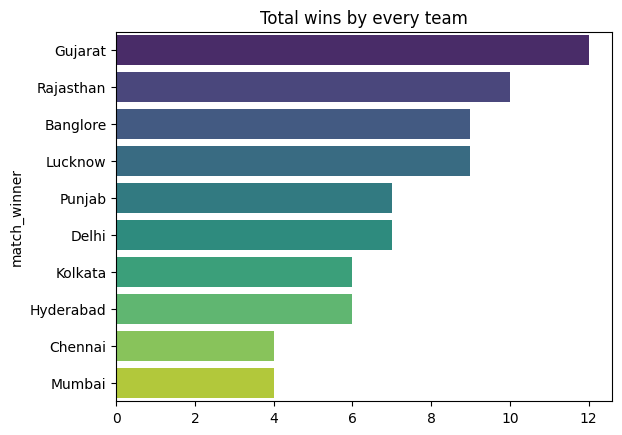

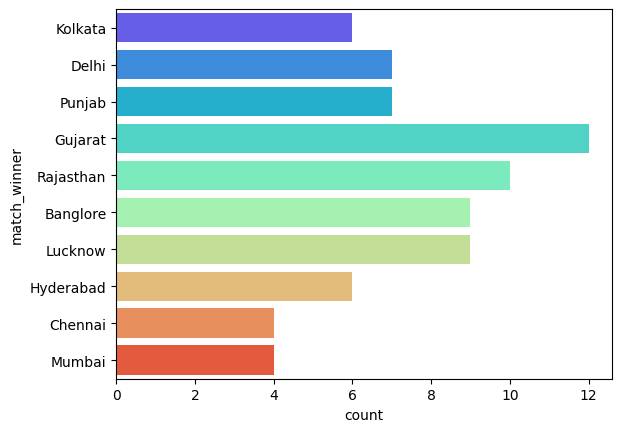

In [5]:
df.head()

#-----------------M1------------------#
match_wins_series = df['match_winner'].value_counts() # df[''].value_counts gives the unique value counts for every unique team in that column 
display(match_wins_series)
# here series ---> is a dictionary with index as match winner and values as counts of it ..

fig = sns.barplot(x = match_wins_series.values , y = match_wins_series.index , palette = 'viridis' , fill=True)
plt.title('Total wins by every team')
plt.savefig('visualization-images/total_wins_per_team_bar_plot.png',bbox_inches = 'tight')
plt.show()

# By count plot , 
sns.countplot( y = 'match_winner' , data = df , palette = 'rainbow' , fill= True)
plt.show()

In [6]:
#----------------M2--------------------#
match_wins = df.groupby(by='match_winner')
display(match_wins.size().sort_values(ascending=False))
display(type(match_wins.size())) 

# remember group by gives us the address of series object never the dataframe 

match_winner
Gujarat      12
Rajasthan    10
Lucknow       9
Banglore      9
Punjab        7
Delhi         7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
dtype: int64

pandas.core.series.Series

#
### Toss Decision Trend Over Matches
#

In [7]:
df.head(5)
# field or bat are two options here

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


toss_decision
Field    59
Bat      15
Name: count, dtype: int64

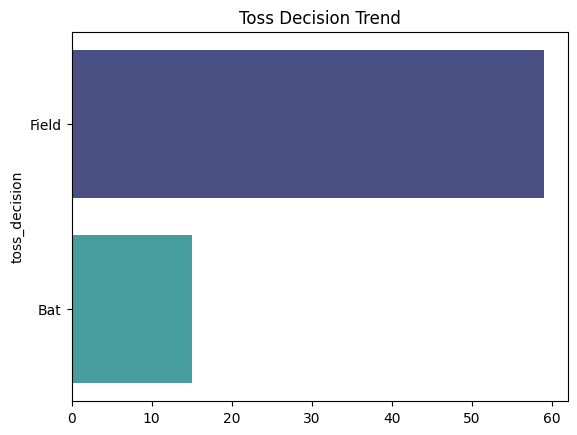




[59 15]


Choosing Field Percentage : 79.73


Choosing  Bat  Percentage : 20.27


In [8]:
toss_trend  = df['toss_decision'].value_counts()
display(toss_trend)

fig  = sns.barplot(x = toss_trend.values , y = toss_trend.index , palette = 'mako')
plt.title('Toss Decision Trend')
plt.savefig('visualization-images/toss_decision_trend_bar_plot.png',bbox_inches = 'tight')
plt.show()

print(f"\n\n\n{toss_trend.values}")
print(f"\n\nChoosing Field Percentage : {(toss_trend.values[0]/df.shape[0])*100 :.2f}")
print(f"\n\nChoosing  Bat  Percentage : {(toss_trend.values[1]/df.shape[0])*100:.2f}")

#
### Toss Winner vs Match Winner Percentage 
#

In [9]:
df.head()
toss_win_vs_match_winner_bool = df['toss_winner'] == df['match_winner']
display(toss_win_vs_match_winner_bool)

df_required_indexes = df[toss_win_vs_match_winner_bool]
display(df_required_indexes.head(5))

print(f" \n\n\nTotal Teams with toss win with match min : {df_required_indexes.shape[0]}")

print(f"\n\nPercentage wins after winning toss          :  {(df_required_indexes.shape[0]/df.shape[0])*100:.2f}")

0      True
1      True
2      True
3      True
4     False
      ...  
69    False
70     True
71    False
72     True
73    False
Length: 74, dtype: bool

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
5,6,"March 30,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Kolkata,Group,Banglore,Field,128,10,132,7,Banglore,Wickets,3,Wanindu Hasaranga,Sherfane Rutherford,28,Wanindu Hasaranga,4--20


 


Total Teams with toss win with match min : 36


Percentage wins after winning toss          :  48.65


False    38
True     36
Name: count, dtype: int64

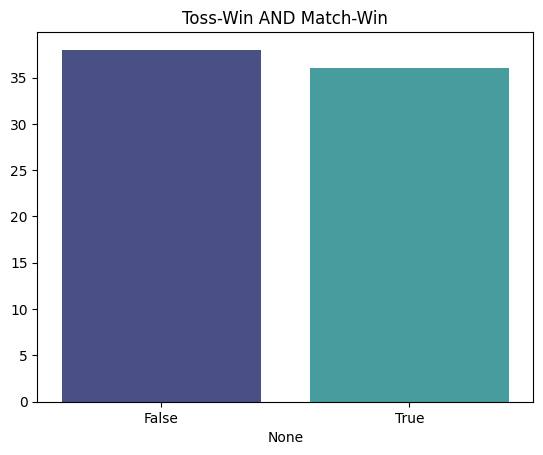

In [137]:
toss_win_vs_match_win_series = toss_win_vs_match_winner_bool.value_counts()
display(toss_win_vs_match_win_series)
sns.barplot(x = toss_win_vs_match_win_series.index , y = toss_win_vs_match_win_series.values , palette = 'mako')
plt.title('Toss-Win AND Match-Win')
plt.savefig('visualization-images/toss_win_and_match_win_bar_plot.png',bbox_inches = 'tight')
plt.show()

#
## Toss Winning Trend Per Team In Group Stage
#

Confirming Total 14 Matches played by Every Team in Group Stage

In [134]:
df_grouped_by_stage = df.groupby(by='stage')
matches_played_team1 = df_grouped_by_stage['team1'].value_counts()
display(matches_played_team1['Group'])

matches_played_team2 = df_grouped_by_stage['team2'].value_counts()
display(matches_played_team2['Group'])
# CONFIRMS 14 MATCHES PLAYED BY EVERY TEAM IN GROUP STAGE ..

team1
Banglore     14
Chennai      12
Delhi        12
Gujarat       8
Hyderabad     7
Kolkata       7
Lucknow       6
Mumbai        3
Punjab        1
Name: count, dtype: int64

team2
Rajasthan    14
Punjab       13
Mumbai       11
Lucknow       8
Hyderabad     7
Kolkata       7
Gujarat       6
Chennai       2
Delhi         2
Name: count, dtype: int64

In [152]:
df.head(1)
toss_wins_trend = df_grouped_by_stage['toss_winner'].value_counts()

toss_win_trend_group_stage     = toss_wins_trend['Group']
toss_win_trend_playoff_stage = toss_wins_trend['Playoff']

print("\n\nToss Winning Trend Out of 14 Group Stage Matches\n") # Toss_Winning_Trend_Out_of_14_group_stage_matches
display(toss_win_trend_group_stage)

print("\n\nToss Winning Trend Out of 3 Playoff Stage Matches\n") # Toss_Winning_Trend_Out_of_14_playoff_stage_matches
display(toss_win_trend_playoff_stage)



Toss Winning Trend Out of 14 Group Stage Matches



toss_winner
Hyderabad    10
Gujarat       9
Mumbai        9
Banglore      8
Delhi         8
Kolkata       8
Chennai       6
Lucknow       6
Punjab        4
Rajasthan     2
Name: count, dtype: int64



Toss Winning Trend Out of 3 Playoff Stage Matches



toss_winner
Gujarat      1
Lucknow      1
Rajasthan    1
Name: count, dtype: int64

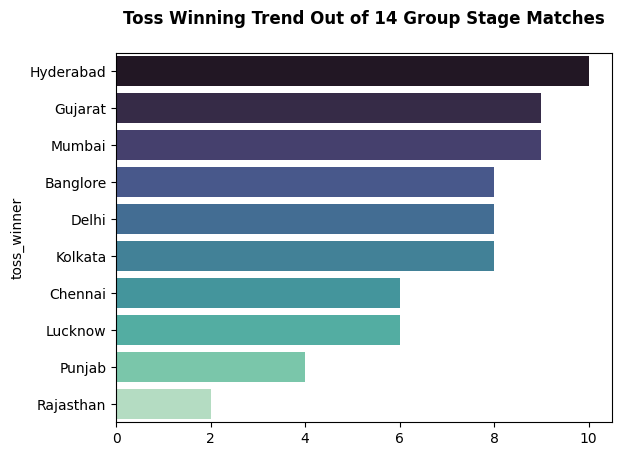

In [153]:
sns.barplot(y = toss_win_trend_group_stage.index , x =toss_win_trend_group_stage.values , palette = 'mako' )
plt.title('Toss Winning Trend Out of 14 Group Stage Matches\n',fontweight = 'bold')
plt.savefig('visualization-images/Toss_Winning_Trend_Out_of_14_group_stage_matches_bar_plot.png',bbox_inches = 'tight')
plt.show()

#
## Toss Winning AND Match Winning Trend Per Team
#

In [168]:
# FIRST , Total toss wins for EACH team
total_toss_wins_per_team = df['toss_winner'].value_counts()
print('\nTotal toss wins for EACH team          : \n')
display(total_toss_wins_per_team)

# SECOND , TOTAL TOSS AND MATCH WIN for each team
df_toss_and_match_winner_bool = df['toss_winner'] == df['match_winner']
df_toss_and_match_win = df[df_toss_and_match_winner_bool]
toss_and_match_win_per_team  = df_toss_and_match_win['match_winner'].value_counts()
print("\nTOTAL TOSS AND MATCH WIN for each team : \n")
display(toss_and_match_win_per_team)

win_percentage_after_winning_toss = (toss_and_match_win_per_team / total_toss_wins_per_team)*100
# IN PANDAS WE CAN DIVIDE OR ADD SERIES WITH SAME INDEXES EVEN IF THEY ARE NOT SAME WAY ORDERED
print("\nMATCH WINS PERCENTAGE AFTER WINNING THE TOSS : \n")
display(round(win_percentage_after_winning_toss.sort_values(ascending = False),2))


Total toss wins for EACH team          : 



toss_winner
Hyderabad    10
Gujarat      10
Mumbai        9
Kolkata       8
Delhi         8
Banglore      8
Lucknow       7
Chennai       6
Punjab        4
Rajasthan     4
Name: count, dtype: int64


TOTAL TOSS AND MATCH WIN for each team : 



match_winner
Gujarat      7
Kolkata      5
Hyderabad    5
Delhi        4
Lucknow      4
Banglore     4
Mumbai       3
Rajasthan    2
Punjab       1
Chennai      1
Name: count, dtype: int64


MATCH WINS PERCENTAGE AFTER WINNING THE TOSS : 



Gujarat      70.00
Kolkata      62.50
Lucknow      57.14
Banglore     50.00
Hyderabad    50.00
Delhi        50.00
Rajasthan    50.00
Mumbai       33.33
Punjab       25.00
Chennai      16.67
Name: count, dtype: float64

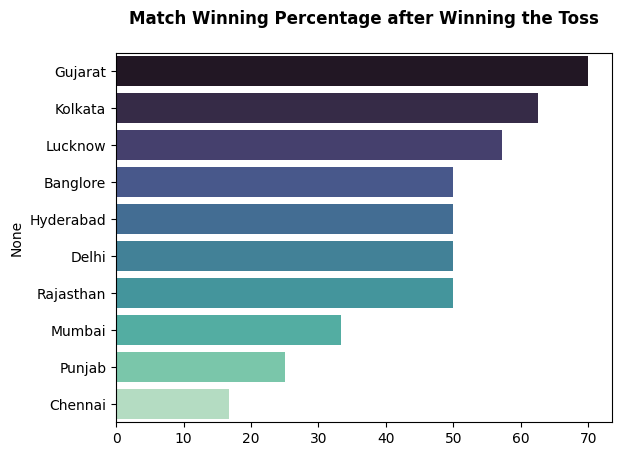

In [179]:
sns.barplot(x = round(win_percentage_after_winning_toss.sort_values(ascending = False),2).values ,
            y = win_percentage_after_winning_toss.sort_values(ascending=False).index , 
            palette = 'mako')
plt.title('Match Winning Percentage after Winning the Toss\n' , fontweight = 'bold')
plt.savefig('visualization-images/match_winning_%_after_winning_toss.png',bbox_inches = 'tight')
plt.show()


#
### Teams Winning Trend ( Runs vs Wickets )
#

In [11]:
df.head()
# we have won by column with won by runs or wickets ..

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


won_by
Wickets    37
Runs       37
Name: count, dtype: int64

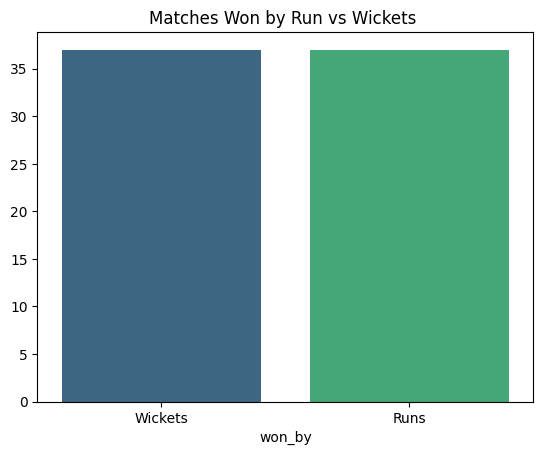

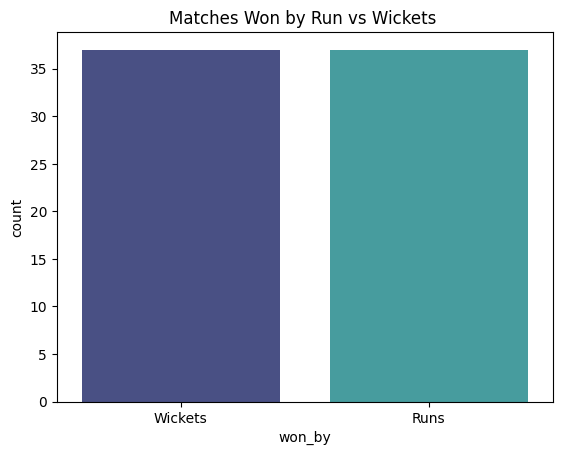

In [12]:
Win_By_Counts = df['won_by'].value_counts()
display(Win_By_Counts)

sns.barplot(x = Win_By_Counts.index , y = Win_By_Counts.values , palette = 'viridis')
plt.title('Matches Won by Run vs Wickets ')
plt.show()

# M2 DIRECT COUNT PLOT ON COLUMN OF WON BY ..
sns.countplot( x = 'won_by' , data =df , palette = 'mako')
plt.title('Matches Won by Run vs Wickets ')
plt.savefig('visualization-images/matches_won_by_runs_vs_wickets_count_plot.png',bbox_inches = 'tight')
plt.show()

#
# 4) KEY PLAYER PERFORMANCES

#
### Most Player of Match Awards (POTM)
#

In [13]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [14]:
top_potm = df['player_of_the_match'].value_counts(ascending = False)
display(top_potm.head(25))

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Wanindu Hasaranga    2
Umesh Yadav          2
Quinton de Kock      2
Shubman Gill         2
Avesh Khan           2
Dinesh Karthik       2
Hardik Pandya        2
Rahul Tripathi       2
K L Rahul            2
Yuzvendra Chahal     2
David Miller         2
Jasprit Bumrah       2
Umran Malik          2
Evin Lewis           1
Abhishek Sharma      1
Pat Cummins          1
Liam Livingstone     1
Lockie Ferguson      1
Shivam Dube          1
Sanju Samson         1
Odean Smith          1
Mohammed Shami       1
Mayank Agarwal       1
Name: count, dtype: int64

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Wanindu Hasaranga    2
Umesh Yadav          2
Quinton de Kock      2
Shubman Gill         2
Avesh Khan           2
Dinesh Karthik       2
Hardik Pandya        2
Rahul Tripathi       2
Name: count, dtype: int64

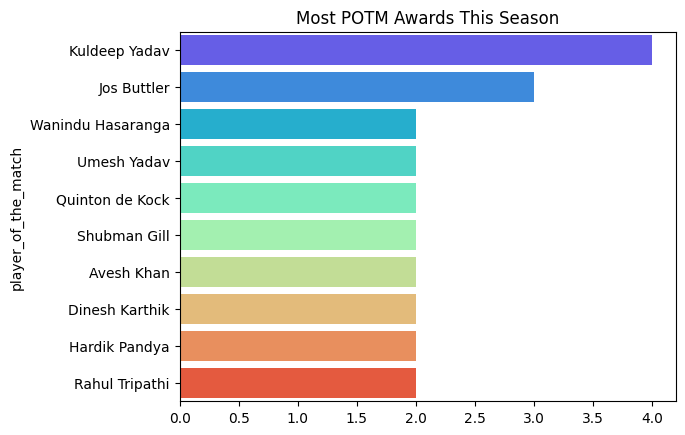

In [15]:
display(top_potm.head(10))

top_10_potm = top_potm.head(10)
sns.barplot( x = top_10_potm.values , y = top_10_potm.index , palette = 'rainbow')
plt.title('Most POTM Awards This Season')
plt.savefig('visualization-images/top_10_potm_awards_season_bar_plot.png',bbox_inches = 'tight')
plt.show()

#
## Most Top Scorer Runs Frequency In All Matches 
#

In [16]:
df.head()
# freq find of every top_scores --> value_counts function on that column 

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [17]:
top_scores_freq = df['top_scorer'].value_counts()
display(top_scores_freq)

top_scorer
Jos Buttler            7
Quinton de Kock        5
Liam Livingstone       4
Shubman Gill           4
KL Rahul               4
Ishan Kishan           3
David Warner           3
W. Saha                3
Faf du Plessis         3
Shikhar Dhawan         2
Deepak Hooda           2
MS Dhoni               2
Abhishek Sharma        2
Devon Conway           2
Hardik Pandya          2
Rahul Tripathi         2
Mitchell Marsh         2
Andre Russell          2
Virat Kohli            2
Aiden Markram          1
Pat Cummins            1
Kane Williamson        1
Shivam Dube            1
Suryakumar Yadav       1
Shimron Hetmyer        1
Sherfane Rutherford    1
David Miller           1
Tilak Varma            1
Dinesh Karthik         1
Nitish Rana            1
Riyan Parag            1
Sanju Samson           1
Ruturaj Gaikwad        1
Sai Sudharsan          1
Yashasvi Jaiswal       1
Moeen Ali              1
Rajat Patidar          1
Name: count, dtype: int64

top_scorer
Jos Buttler         7
Quinton de Kock     5
Liam Livingstone    4
Shubman Gill        4
KL Rahul            4
Ishan Kishan        3
David Warner        3
W. Saha             3
Faf du Plessis      3
Shikhar Dhawan      2
Name: count, dtype: int64

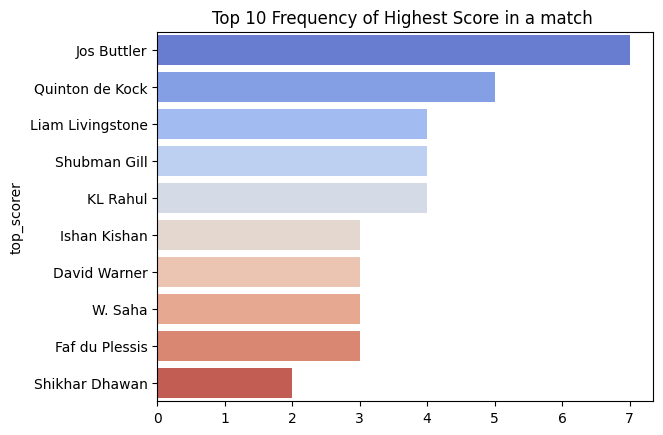

In [18]:
top_10_top_scorer_freq = top_scores_freq.head(10)
display(top_10_top_scorer_freq)

sns.barplot( x = top_10_top_scorer_freq.values , y = top_10_top_scorer_freq.index  , palette = 'coolwarm')
plt.title('Top 10 Frequency of Highest Score in a match ')

plt.savefig('visualization-images/top_10_highest_score_freq_bar_plot.png',bbox_inches = 'tight')
plt.show()

## Best Bowling Figure  ( Feature Extraction )

                                         Extraction Process

In [19]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [20]:
# FEATURE EXTRACTION ...

def get_best_bowling_wicket_dry_run(best_bowling_figure) :

    figure = best_bowling_figure
    
    start = 0
    end   = figure.find('--')
    print(f"end    : {end}")

    best_bowling_wickets_string = figure[start:end]
    print(f"best_bowling_wickets_string : {best_bowling_wickets_string} ")

    cleaned_best_bowling_wickets_string  = best_bowling_wickets_string.strip()
    
    return int(best_bowling_wickets_string)

df['best_bowling_figure'].loc[[0,1,2,3,4]].apply(get_best_bowling_wicket_dry_run)
df['best_bowling_figure'].head()


end    : 1
best_bowling_wickets_string : 3 
end    : 1
best_bowling_wickets_string : 3 
end    : 1
best_bowling_wickets_string : 2 
end    : 1
best_bowling_wickets_string : 3 
end    : 1
best_bowling_wickets_string : 3 


0    3--20
1    3--18
2    2--59
3    3--25
4    3--22
Name: best_bowling_figure, dtype: object

In [21]:
def get_best_bowling_wicket(best_bowling_figure) :

    figure = best_bowling_figure
    
    start = 0
    end   = figure.find('--')
    best_bowling_wickets_string = figure[start:end]
    cleaned_best_bowling_wickets_string  = best_bowling_wickets_string.strip()
    
    return int(best_bowling_wickets_string)

df['bb_wkt'] = df['best_bowling_figure'].apply(get_best_bowling_wicket)

In [22]:
display(df.head(1))
display(df.info())

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,bb_wkt
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

None

In [23]:
def get_best_bowling_runs_dry_run(best_bowling_figure):

    figure = best_bowling_figure
    start  = figure.rfind('--') # reverse find is used to find index from last 
    print(f"start          : {start}")

    figure = figure[start+2:]
    print(f"bb_runs_string : {figure} {type(figure)}")
    figure = int(figure)
    print(type(figure))

    return figure
    
df['best_bowling_figure'].loc[[0,1,2]].apply(get_best_bowling_runs_dry_run)

start          : 1
bb_runs_string : 20 <class 'str'>
<class 'int'>
start          : 1
bb_runs_string : 18 <class 'str'>
<class 'int'>
start          : 1
bb_runs_string : 59 <class 'str'>
<class 'int'>


0    20
1    18
2    59
Name: best_bowling_figure, dtype: int64

In [24]:
def get_best_bowling_runs(best_bowling_figure):

    figure = best_bowling_figure
    start  = figure.rfind('--') # reverse find is used to find index from last 
    figure = figure[start+2:]
    figure = int(figure)
    return figure
    
df['bb_runs'] = df['best_bowling_figure'].apply(get_best_bowling_runs)
df.head(5)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

#
                                             BEST BOWLING FIGURE ANALYSIS PROCESS
#                                             

In [25]:
df.head(1)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,bb_wkt,bb_runs
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3,20


In [26]:
df_required = df[['best_bowling' , 'best_bowling_figure' , 'bb_wkt' , 'bb_runs']]
df_required.head()

df_sorted_by_bb = df_required.sort_values(by = ['bb_wkt','bb_runs'] , ascending = [False,True])

display(df_sorted_by_bb[['best_bowling_figure','best_bowling']].head(25))

,best_bowling_figure,best_bowling
55,5--10,Jasprit Bumrah
53,5--18,Wanindu Hasaranga
39,5--25,Umran Malik
29,5--40,Yuzvendra Chahal
34,4--5,Andre Russell
40,4--14,Kuldeep Yadav
44,4--16,Mohsin Khan
5,4--20,Wanindu Hasaranga
38,4--20,Kuldeep Sen
7,4--23,Umesh Yadav


## Most Wickets and Least Economy In Single Match

In [27]:
df_sorted_by_bb.head()

,best_bowling,best_bowling_figure,bb_wkt,bb_runs
55,Jasprit Bumrah,5--10,5,10
53,Wanindu Hasaranga,5--18,5,18
39,Umran Malik,5--25,5,25
29,Yuzvendra Chahal,5--40,5,40
34,Andre Russell,4--5,4,5


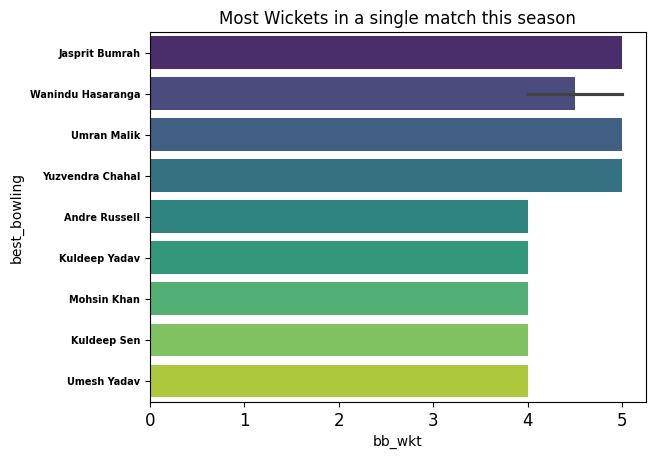

In [28]:
sns.barplot( x = 'bb_wkt' , y = 'best_bowling' , data = df_sorted_by_bb.head(10) , palette = 'viridis',gap=0)
plt.title('Most Wickets in a single match this season')
plt.xticks(fontsize=12)
plt.yticks(fontsize=7, fontweight='bold')
plt.savefig('visualization-images/top_10_most_wickets_single_match.png',bbox_inches = 'tight')
plt.show()

,best_bowling,best_bowling_figure,bb_wkt,bb_runs
0,Dwayne Bravo,3--20,3,20
1,Kuldeep Yadav,3--18,3,18
2,Mohammed Siraj,2--59,2,59
3,Mohammed Shami,3--25,3,25
4,Yuzvendra Chahal,3--22,3,22


,best_bowling,best_bowling_figure,bb_wkt,bb_runs
34,Andre Russell,4--5,4,5
31,Axar Patel,2--10,2,10
35,T Natarajan,3--10,3,10
55,Jasprit Bumrah,5--10,5,10
54,Moeen Ali,3--13,3,13


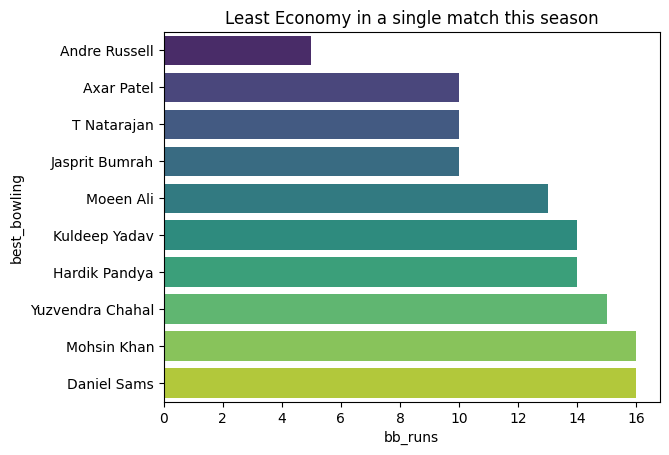

In [29]:
display(df_required.head())
df_required_economy_sorted = df_required.sort_values( by = 'bb_runs' , ascending = True)
display(df_required_economy_sorted.head())
sns.barplot( x = 'bb_runs' , y = 'best_bowling' , data = df_required_economy_sorted.head(10) , palette = 'viridis')
plt.title('Least Economy in a single match this season')
plt.savefig('visualization-images/top_10_least_economy_single_match.png',bbox_inches = 'tight')
plt.show()

#
# 5) VENUE ANALYSIS
#

## Total Matches Played at every Venue 
#

In [30]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,bb_wkt,bb_runs
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3,20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3,18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2,59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3,25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3,22


venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

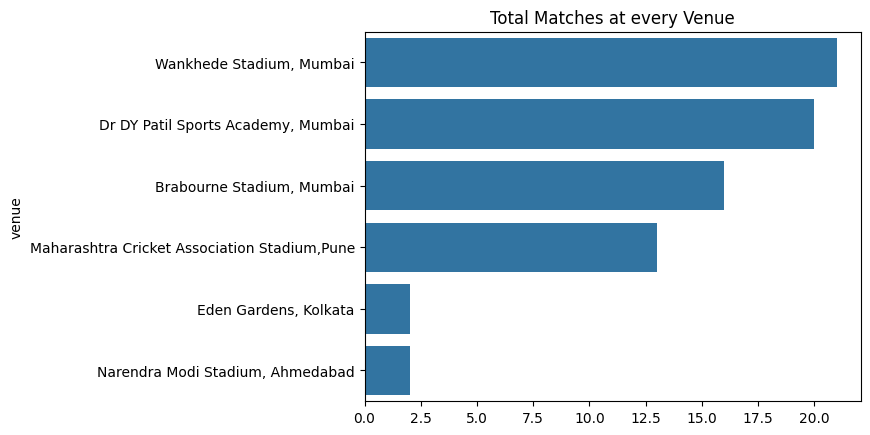

In [31]:
venue_matches_counts = df['venue'].value_counts()
display(venue_matches_counts)

sns.barplot( x = venue_matches_counts.values ,  y = venue_matches_counts.index )
plt.title('Total Matches at every Venue')
plt.savefig('visualization-images/matches_played_at_every_venue_bar_plot.png',bbox_inches = 'tight')
plt.show()

#
## Venue Better for Chasing(Bowl first) or Defending(Bat first) 
#

In [32]:
df.head(1)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,bb_wkt,bb_runs
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3,20


In [33]:
df_grouped_by_venue =  df.groupby('venue')  # now the index is venue

win_percentage_counts_by_venue = df_grouped_by_venue['won_by'].value_counts(normalize = True)*100
display(win_percentage_counts_by_venue) # normalize = true gives us percentage 
# simple value_counts on won_by column will have simple index (1-74)

print("\n\nMULTIINDEX SERIES :\n")
display(win_percentage_counts_by_venue.index)
print("\n\nVALUES            :\n")
display(win_percentage_counts_by_venue.values)

# VALUE_COUNTS() -> gives us a series object as a dictionary and which has an index and value
                #-> here when we grouped by venue index became venue , now per venue we did value_counts of won_by but won_by has two values
                #-> thus a MULTIINDEX SERIES HAS BEEN CREATED with index as ['venue','wickets'] and ['venue','runs'] 
                #-> we need to CONVERT THIS INDEX TO SINGLE INDEX NAME as won_by is trapped inside index itself ..
                #-> to convert it into single index we need to have an index like -> venue-runs or venue-wickets and values same as before 

venue                                         won_by 
Brabourne Stadium, Mumbai                     Runs        50.000000
                                              Wickets     50.000000
Dr DY Patil Sports Academy, Mumbai            Runs        50.000000
                                              Wickets     50.000000
Eden Gardens, Kolkata                         Runs        50.000000
                                              Wickets     50.000000
Maharashtra Cricket Association Stadium,Pune  Runs        76.923077
                                              Wickets     23.076923
Narendra Modi Stadium, Ahmedabad              Wickets    100.000000
Wankhede Stadium, Mumbai                      Wickets     61.904762
                                              Runs        38.095238
Name: proportion, dtype: float64



MULTIINDEX SERIES :



MultiIndex([(                   'Brabourne Stadium, Mumbai',    'Runs'),
            (                   'Brabourne Stadium, Mumbai', 'Wickets'),
            (          'Dr DY Patil Sports Academy, Mumbai',    'Runs'),
            (          'Dr DY Patil Sports Academy, Mumbai', 'Wickets'),
            (                       'Eden Gardens, Kolkata',    'Runs'),
            (                       'Eden Gardens, Kolkata', 'Wickets'),
            ('Maharashtra Cricket Association Stadium,Pune',    'Runs'),
            ('Maharashtra Cricket Association Stadium,Pune', 'Wickets'),
            (            'Narendra Modi Stadium, Ahmedabad', 'Wickets'),
            (                    'Wankhede Stadium, Mumbai', 'Wickets'),
            (                    'Wankhede Stadium, Mumbai',    'Runs')],
           names=['venue', 'won_by'])



VALUES            :



array([ 50.        ,  50.        ,  50.        ,  50.        ,
        50.        ,  50.        ,  76.92307692,  23.07692308,
       100.        ,  61.9047619 ,  38.0952381 ])


SINGLENDEX SERIES :



['Brabourne Stadium, Mumbai - WinBy - Runs',
 'Brabourne Stadium, Mumbai - WinBy - Wickets',
 'Dr DY Patil Sports Academy, Mumbai - WinBy - Runs',
 'Dr DY Patil Sports Academy, Mumbai - WinBy - Wickets',
 'Eden Gardens, Kolkata - WinBy - Runs',
 'Eden Gardens, Kolkata - WinBy - Wickets',
 'Maharashtra Cricket Association Stadium,Pune - WinBy - Runs',
 'Maharashtra Cricket Association Stadium,Pune - WinBy - Wickets',
 'Narendra Modi Stadium, Ahmedabad - WinBy - Wickets',
 'Wankhede Stadium, Mumbai - WinBy - Wickets',
 'Wankhede Stadium, Mumbai - WinBy - Runs']


VALUES:


array([ 50.        ,  50.        ,  50.        ,  50.        ,
        50.        ,  50.        ,  76.92307692,  23.07692308,
       100.        ,  61.9047619 ,  38.0952381 ])

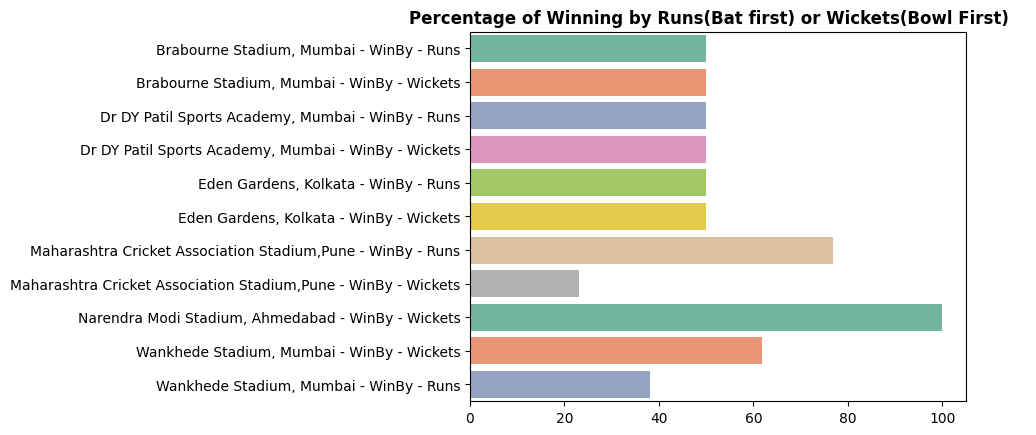

In [34]:
# INDEX PORTION OF BAR PLOT 

venue_plus_wonby_method_index = [] # starting with empty list

for venue , method in win_percentage_counts_by_venue.index :
    new_single_index = venue + " - WinBy - " + method
    venue_plus_wonby_method_index.append(new_single_index)
print("\nSINGLENDEX SERIES :\n")
display(venue_plus_wonby_method_index)

# VALUES PORTION OF BAR PLOT 
print("\nVALUES:")
display(win_percentage_counts_by_venue.values)

# BARPLOT CREATION
sns.barplot( y  = venue_plus_wonby_method_index ,  x = win_percentage_counts_by_venue.values , palette ='Set2')
plt.title('Percentage of Winning by Runs(Bat first) or Wickets(Bowl First)   ',fontweight = 'bold')
plt.savefig('visualization-images/percentage_winning_by_bowlfirst_batfirst_per_venue_bar_plot.png',bbox_inches = 'tight')
plt.show()

#
## First Innings Score Consistency at Venues
#

In [35]:
df.head(1)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,bb_wkt,bb_runs
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3,20


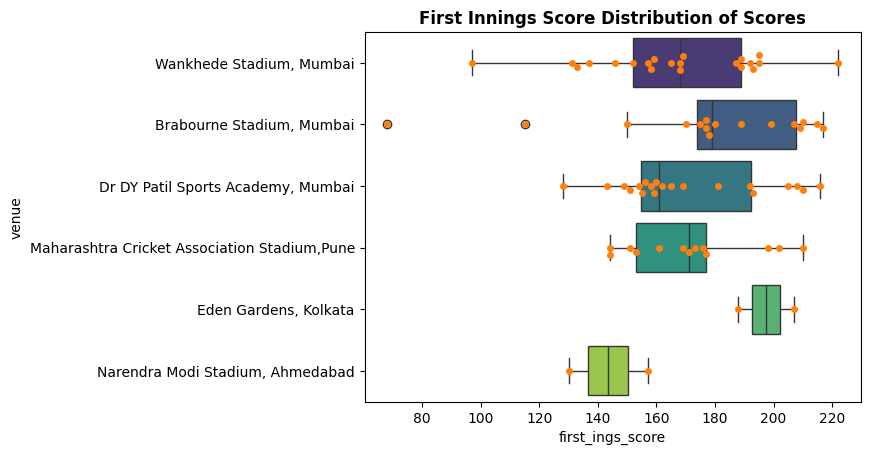

In [36]:
sns.boxplot( x = 'first_ings_score' , y = 'venue' , data = df , palette = 'viridis')
sns.swarmplot( x = 'first_ings_score' , y = 'venue' , data = df)
plt.title('First Innings Score Distribution of Scores',fontweight = 'bold')
plt.savefig('visualization-images/first_innings_score_distribution_swarm_box_plot.png',bbox_inches = 'tight')

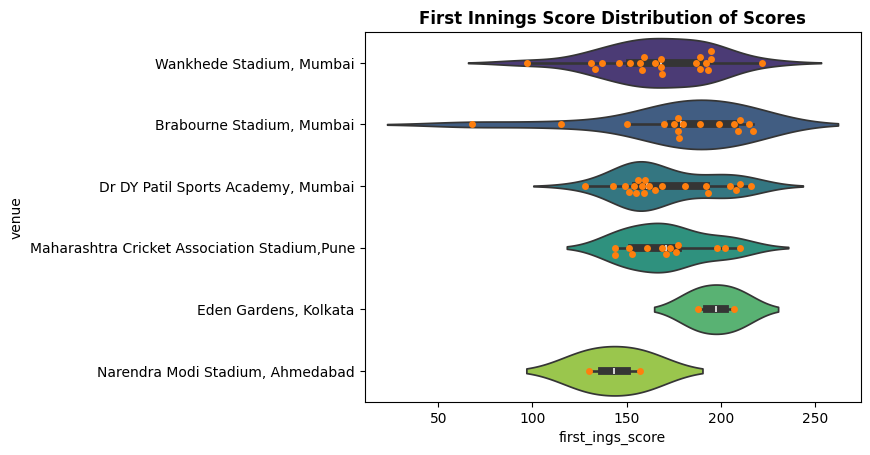

In [37]:
sns.violinplot( x = 'first_ings_score' , y = 'venue' , data = df , palette = 'viridis')
sns.swarmplot( x = 'first_ings_score' , y = 'venue' , data = df)
plt.title('First Innings Score Distribution of Scores',fontweight = 'bold')
plt.savefig('visualization-images/first_innings_score_distribution_strech_violin_swarm_plot.png',bbox_inches = 'tight')

# Insights of Venue First Innings

Wankhede was the busiest: It has the most dots, meaning it hosted a lot of games. You can see a big clump of dots between 150 and 170, meaning that is the most common score there.

Narendra Modi Stadium is a bowler's pitch: This stadium has the lowest scores of all. Teams really struggled to score big here, usually only making between 130 and 160 runs.

Small sample size for the bottom two: Eden Gardens and Narendra Modi Stadium only have a few dots. It means fewer matches were played there, so we can't make huge guesses about the pitch, but they mostly sat in the 160–190 range.

Brabourne Stadium is a total wildcard: You never know what will happen here. A team might get bundled out for 115, or they might smash over 215. It is the most unpredictable pitch in the tournament.

Pune is completely random: The dots for Pune are stretched all the way from the bottom to the top. Teams either scored really low (around 140) or really high (over 200). It is not a predictable pitch.

Eden Gardens is consistently high-scoring: If a match is played here, you can almost guarantee the team batting first will score a solid 160 to 200 runs. It doesn't have the crazy low scores that other pitches have.

Mumbai pitches (Wankhede & DY Patil) are twins: They play very similarly. You can normally expect a score around 165 at both of these grounds.

#
## Toss Decision Trends at Venues
#

In [38]:
df.head(1)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,bb_wkt,bb_runs
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3,20


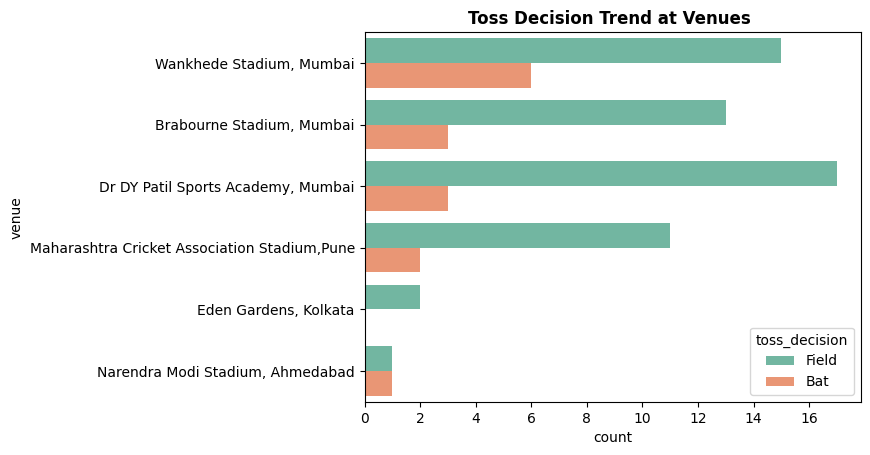

In [39]:
# In a countplot what we do is we pass the categorical data in y axis and x axes the quantative data count  by hue = 'toss_decison' counts

sns.countplot(y = 'venue' , hue = 'toss_decision', data = df , palette = 'Set2')
plt.title('Toss Decision Trend at Venues ',fontweight = 'bold')
plt.savefig('visualization-images/toss_decison_trend_venues_count_plot.png',bbox_inches = 'tight')

#
# 6) MARGIN AND WIN METHOD ANALYSIS
#

## Which Teams won by Highest Margin on Average over the season..
## Rank Teams with their quality of defending a total..

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,bb_wkt,bb_runs
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3,20


,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,bb_wkt,bb_runs
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3,22


Team : Banglore     ||    Avg Margin while Winning by defending  : 25.6 
Team : Chennai      ||    Avg Margin while Winning by defending  : 42.3 
Team : Delhi        ||    Avg Margin while Winning by defending  : 27.3 
Team : Gujarat      ||    Avg Margin while Winning by defending  : 30.2 
Team : Hyderabad    ||    Avg Margin while Winning by defending  : 3.0 
Team : Kolkata      ||    Avg Margin while Winning by defending  : 53.0 
Team : Lucknow      ||    Avg Margin while Winning by defending  : 24.1 
Team : Mumbai       ||    Avg Margin while Winning by defending  : 5.0 
Team : Punjab       ||    Avg Margin while Winning by defending  : 32.8 
Team : Rajasthan    ||    Avg Margin while Winning by defending  : 23.1 


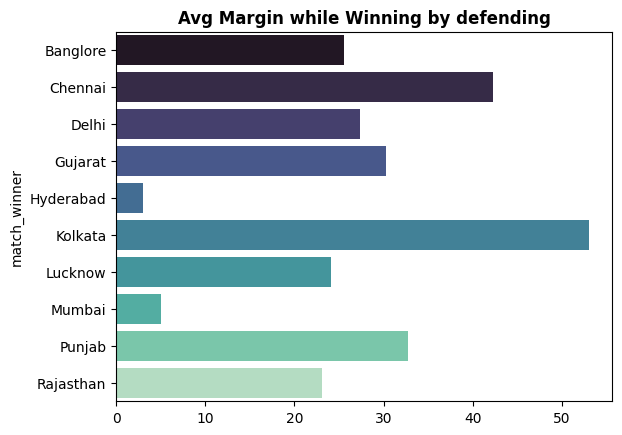

In [53]:
display(df.head(1))


# matches won by runs i.e defending a total 
df_matches_won_by_runs_bool =  df['won_by'] == 'Runs'
df_matches_won_by_runs = df[df_matches_won_by_runs_bool]
display(df_matches_won_by_runs.head(1))

# now calculating avergae margin grouping dataframe by teams 

# group by match winner means every team as an index with matches as columns win by runs(defending)
df_defending_teams = df_matches_won_by_runs.groupby('match_winner')['margin'].mean()

for team , margin in df_defending_teams.items() : 
    print(f"Team : {team:<12} ||    Avg Margin while Winning by defending  : {margin:.1f} ")

sns.barplot( x = df_defending_teams.values , y = df_defending_teams.index , palette = 'mako')
plt.title('Avg Margin while Winning by defending',fontweight = 'bold')
plt.savefig('visualization-images/avg_margin_while_winning_by_defending.png',bbox_inches = 'tight')
plt.show()

#
## Which Teams won by Highest Wickets While Chasing on Average over the season
## Rank Teams with their quality of Chasing a total 
#

In [88]:
df.head(1)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,bb_wkt,bb_runs
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3,20



Avg Margin of Winning by Wickets While Chasing  : 



match_winner
Banglore     5.50
Chennai      3.00
Delhi        6.25
Gujarat      5.75
Hyderabad    7.80
Kolkata      6.00
Lucknow      6.00
Mumbai       5.00
Punjab       6.00
Rajasthan    6.00
Name: margin, dtype: float64

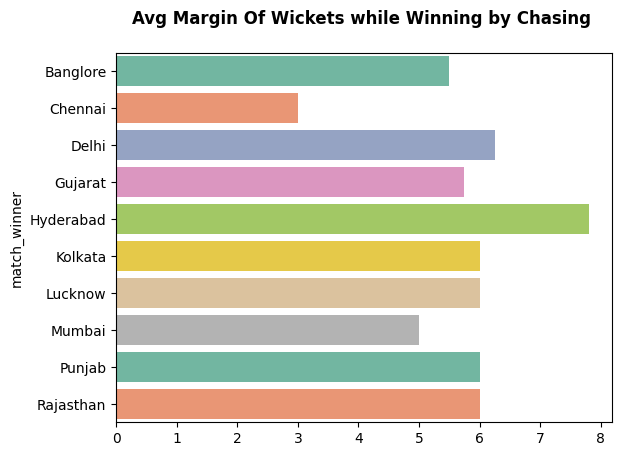

In [102]:
df_won_by_wickets_bool = df['won_by']=='Wickets'
df_matches_won_by_wickets = df[df_won_by_wickets_bool]
df_matches_won_by_wickets_per_team = df_matches_won_by_wickets.groupby(by = 'match_winner')['margin'].mean()

print("\nAvg Margin of Winning by Wickets While Chasing  : \n")
display(df_matches_won_by_wickets_per_team)

sns.barplot( x = df_matches_won_by_wickets_per_team.values , y = df_matches_won_by_wickets_per_team.index , palette = 'Set2')
plt.title('Avg Margin Of Wickets while Winning by Chasing \n',fontweight = 'bold')
plt.savefig('visualization-images/avg_margin_while_winning_by_chasing_bar_plot.png',bbox_inches = 'tight')
plt.show()

#
# No of times Teams Won by Chasing AND Defending Trend Per Team
#

In [64]:
# No of times Teams won by Defending 
df_won_by_runs_bool = df['won_by'] == 'Runs'
df_matches_won_by_runs = df[df_won_by_runs_bool]

df_matches_won_by_runs_grp_teams = df_matches_won_by_runs.groupby('match_winner')
df_won_by_run_counts_per_team = df_matches_won_by_runs_grp_teams['match_winner'].value_counts()
print("\n\n           No of times Team Won by Defending: \n")
display(df_won_by_run_counts_per_team)


# No of times Teams won by Chasing
df_won_by_wickets_bool = df['won_by'] == 'Wickets'
df_matches_won_by_wickets = df[df_won_by_wickets_bool]

df_matches_won_by_wickets_grp_teams = df_matches_won_by_wickets.groupby('match_winner')
df_won_by_wickets_counts_per_team = df_matches_won_by_wickets_grp_teams['match_winner'].value_counts()
print("\n\n           No of times Team Won by Chasing: \n")
display(df_won_by_wickets_counts_per_team)





           No of times Team Won by Defending: 



match_winner
Banglore     5
Chennai      3
Delhi        3
Gujarat      4
Hyderabad    1
Kolkata      2
Lucknow      7
Mumbai       1
Punjab       4
Rajasthan    7
Name: count, dtype: int64



           No of times Team Won by Chasing: 



match_winner
Banglore     4
Chennai      1
Delhi        4
Gujarat      8
Hyderabad    5
Kolkata      4
Lucknow      2
Mumbai       3
Punjab       3
Rajasthan    3
Name: count, dtype: int64

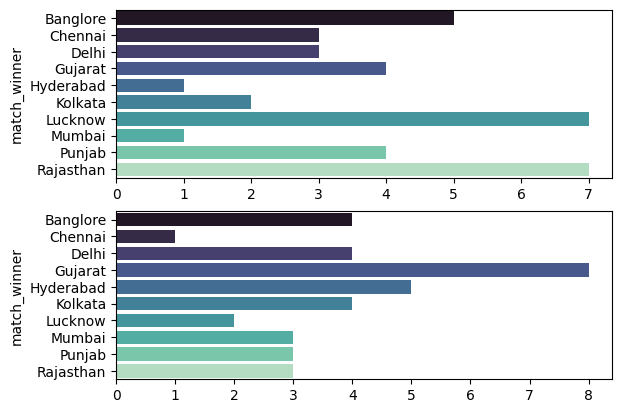

In [86]:
plt.subplot(2,1,1)
sns.barplot(y = df_won_by_run_counts_per_team.index ,x=df_won_by_run_counts_per_team.values,palette= 'mako')
plt.subplot(2,1,2)
sns.barplot(y = df_won_by_wickets_counts_per_team.index ,x=df_won_by_wickets_counts_per_team.values,palette= 'mako')
plt.savefig('visualization-images/no_of_times_teams_won_by_runs_or_wicket_bar_plots.png',bbox_inches = 'tight')
plt.show()

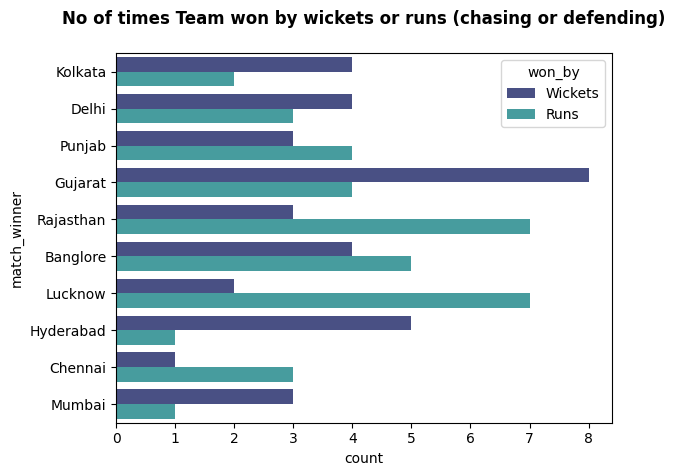

In [85]:
sns.countplot(y= 'match_winner',hue='won_by',data=df,palette = 'mako')
plt.title('No of times Team won by wickets or runs (chasing or defending)\n' , fontweight = 'bold')
plt.savefig('visualization-images/no_of_times_teams_won_by_runs_or_wickets_count_plot.png',bbox_inches = 'tight')
plt.show()